# MNIST Handwritten Digit Recognition



## 1. Setup

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.datasets import mnist
from sklearn.metrics import confusion_matrix

sns.set_style('white')
RANDOM_STATE = 42
tf.random.set_seed(RANDOM_STATE)
np.random.seed(RANDOM_STATE)

## 2. Load and inspect MNIST

In [2]:
(x_train_full, y_train_full), (x_test, y_test) = mnist.load_data()
print(f'Training set: {x_train_full.shape}')
print(f'Test set: {x_test.shape}')
print(f'Pixel value range: {x_train_full.min()} to {x_train_full.max()}')
print(f'Classes: {sorted(np.unique(y_train_full))}')

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Training set: (60000, 28, 28)
Test set: (10000, 28, 28)
Pixel value range: 0 to 255
Classes: [np.uint8(0), np.uint8(1), np.uint8(2), np.uint8(3), np.uint8(4), np.uint8(5), np.uint8(6), np.uint8(7), np.uint8(8), np.uint8(9)]


### Figure 1: Sample digits

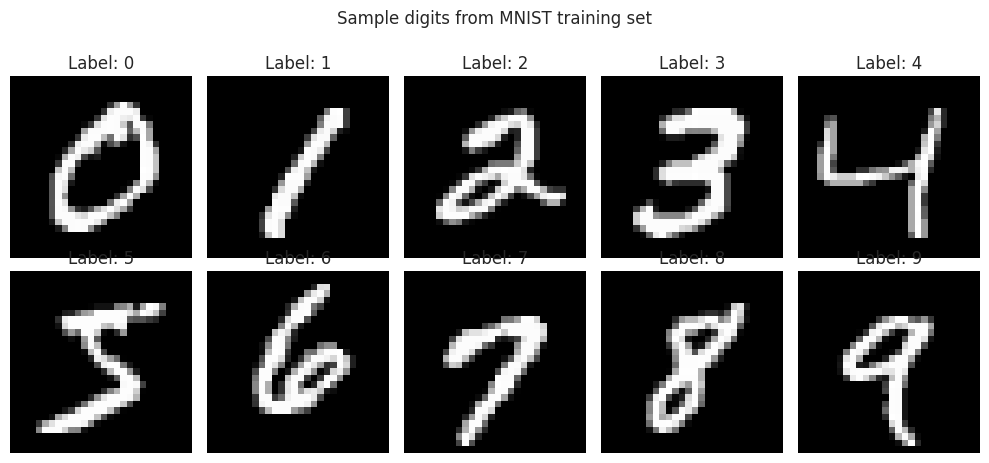

In [3]:
fig, axes = plt.subplots(2, 5, figsize=(10, 4.5))
for digit in range(10):
    ax = axes[digit // 5, digit % 5]
    idx = np.where(y_train_full == digit)[0][0]
    ax.imshow(x_train_full[idx], cmap='gray')
    ax.set_title(f'Label: {digit}')
    ax.axis('off')
plt.suptitle('Sample digits from MNIST training set', y=1.02)
plt.tight_layout()
plt.savefig('fig1_samples.png', dpi=150, bbox_inches='tight')
plt.show()

## 3. Preprocessing

- Normalise pixel values from 0-255 to 0-1
- Reshape to add a channel dimension (28, 28, 1) for the CNN
- Split the 60k training set into 80% train / 20% validation

In [4]:
x_train_full = x_train_full.astype('float32') / 255.0
x_test = x_test.astype('float32') / 255.0
x_train_full = x_train_full.reshape(-1, 28, 28, 1)
x_test = x_test.reshape(-1, 28, 28, 1)

val_size = 12000
x_val = x_train_full[:val_size]
y_val = y_train_full[:val_size]
x_train = x_train_full[val_size:]
y_train = y_train_full[val_size:]

print(f'Train: {x_train.shape}')
print(f'Validation: {x_val.shape}')
print(f'Test: {x_test.shape}')

Train: (48000, 28, 28, 1)
Validation: (12000, 28, 28, 1)
Test: (10000, 28, 28, 1)


## 4. Building the CNN

In [5]:
model = models.Sequential([
    layers.Conv2D(32, (3, 3), activation='relu', input_shape=(28, 28, 1)),
    layers.MaxPooling2D((2, 2)),
    layers.Conv2D(64, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),
    layers.Flatten(),
    layers.Dense(64, activation='relu'),
    layers.Dense(10, activation='softmax')
])

model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 26, 26, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 13, 13, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 11, 11, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 5, 5, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 1600)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │       102,464 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 121,930 (476.29 KB)

 Trainable params: 121,930 (476.29 KB)

 Non-trainable params: 0 (0.00 B)

## 5. Training the model

In [6]:
history = model.fit(
    x_train, y_train,
    epochs=10,
    batch_size=32,
    validation_data=(x_val, y_val),
    verbose=2
)

Epoch 1/10
1500/1500 - 27s - 18ms/step - accuracy: 0.9537 - loss: 0.1536 - val_accuracy: 0.9817 - val_loss: 0.0620
Epoch 2/10
1500/1500 - 26s - 17ms/step - accuracy: 0.9843 - loss: 0.0495 - val_accuracy: 0.9830 - val_loss: 0.0595
Epoch 3/10
1500/1500 - 26s - 17ms/step - accuracy: 0.9895 - loss: 0.0329 - val_accuracy: 0.9846 - val_loss: 0.0562
Epoch 4/10
1500/1500 - 24s - 16ms/step - accuracy: 0.9921 - loss: 0.0239 - val_accuracy: 0.9865 - val_loss: 0.0522
Epoch 5/10
1500/1500 - 42s - 28ms/step - accuracy: 0.9943 - loss: 0.0176 - val_accuracy: 0.9881 - val_loss: 0.0475
Epoch 6/10
1500/1500 - 26s - 17ms/step - accuracy: 0.9954 - loss: 0.0138 - val_accuracy: 0.9871 - val_loss: 0.0508
Epoch 7/10
1500/1500 - 26s - 17ms/step - accuracy: 0.9965 - loss: 0.0104 - val_accuracy: 0.9868 - val_loss: 0.0617
Epoch 8/10
1500/1500 - 41s - 27ms/step - accuracy: 0.9972 - loss: 0.0089 - val_accuracy: 0.9862 - val_loss: 0.0714
Epoch 9/10
1500/1500 - 26s - 17ms/step - accuracy: 0.9972 - loss: 0.0085 - val_a

### Figure 2: Training and validation curves

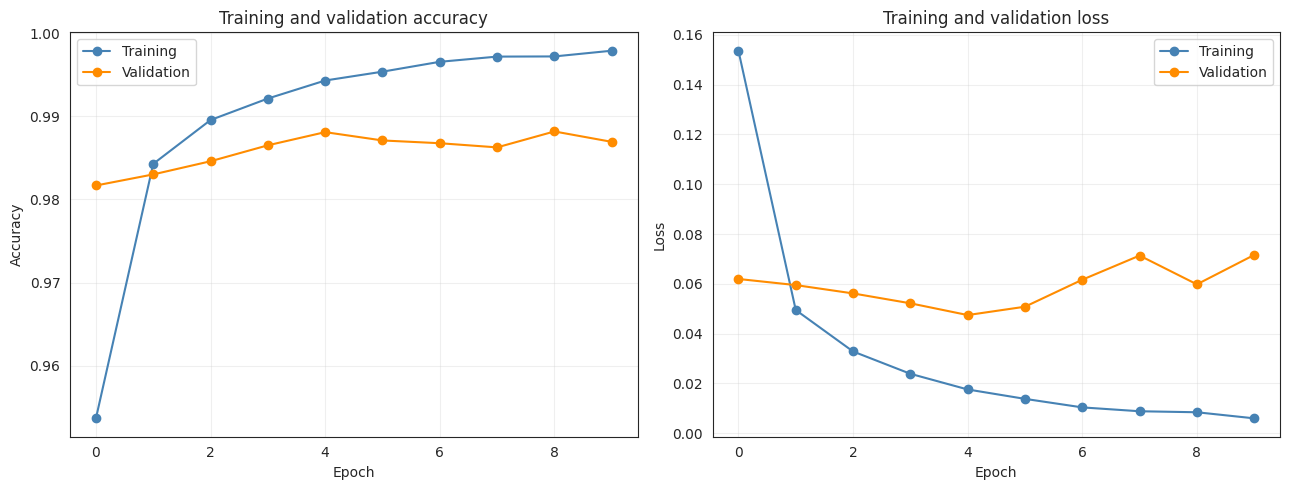

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

axes[0].plot(history.history['accuracy'], 'o-', label='Training', color='steelblue')
axes[0].plot(history.history['val_accuracy'], 'o-', label='Validation', color='darkorange')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Accuracy')
axes[0].set_title('Training and validation accuracy')
axes[0].legend()
axes[0].grid(alpha=0.3)

axes[1].plot(history.history['loss'], 'o-', label='Training', color='steelblue')
axes[1].plot(history.history['val_loss'], 'o-', label='Validation', color='darkorange')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Loss')
axes[1].set_title('Training and validation loss')
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.savefig('fig2_curves.png', dpi=150, bbox_inches='tight')
plt.show()

## 6. Evaluate on the test set

In [8]:
test_loss, test_acc = model.evaluate(x_test, y_test, verbose=0)
print(f'Test accuracy: {test_acc:.4f}')
print(f'Test loss: {test_loss:.4f}')

Test accuracy: 0.9901
Test loss: 0.0496


### Figure 3: Confusion matrix

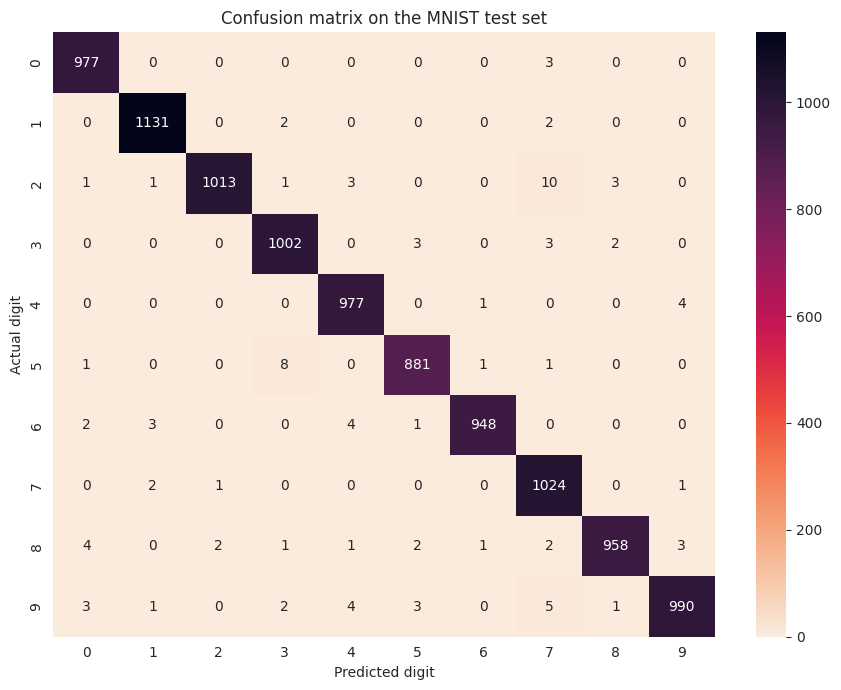

In [9]:
y_pred = np.argmax(model.predict(x_test, verbose=0), axis=1)
cm = confusion_matrix(y_test, y_pred)

fig, ax = plt.subplots(figsize=(9, 7))
sns.heatmap(cm, annot=True, fmt='d', cmap='rocket_r', cbar=True, ax=ax)
ax.set_xlabel('Predicted digit')
ax.set_ylabel('Actual digit')
ax.set_title('Confusion matrix on the MNIST test set')
plt.tight_layout()
plt.savefig('fig3_confusion.png', dpi=150, bbox_inches='tight')
plt.show()

### Figure 4: Example predictions (correct and incorrect)

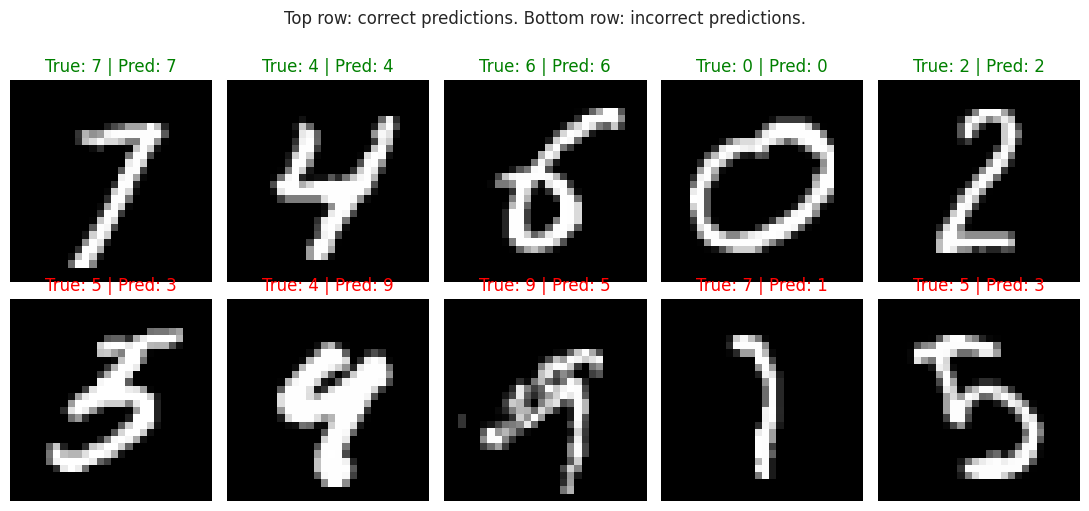

In [10]:
correct_idx = np.where(y_pred == y_test)[0]
wrong_idx = np.where(y_pred != y_test)[0]

fig, axes = plt.subplots(2, 5, figsize=(11, 5))

np.random.seed(RANDOM_STATE)
shown_correct = np.random.choice(correct_idx, 5, replace=False)
shown_wrong = np.random.choice(wrong_idx, 5, replace=False)

for i, idx in enumerate(shown_correct):
    ax = axes[0, i]
    ax.imshow(x_test[idx].squeeze(), cmap='gray')
    ax.set_title(f'True: {y_test[idx]} | Pred: {y_pred[idx]}', color='green')
    ax.axis('off')

for i, idx in enumerate(shown_wrong):
    ax = axes[1, i]
    ax.imshow(x_test[idx].squeeze(), cmap='gray')
    ax.set_title(f'True: {y_test[idx]} | Pred: {y_pred[idx]}', color='red')
    ax.axis('off')

plt.suptitle('Top row: correct predictions. Bottom row: incorrect predictions.', y=1.02)
plt.tight_layout()
plt.savefig('fig4_predictions.png', dpi=150, bbox_inches='tight')
plt.show()